In [1]:
import pandas as pd
from scipy import stats
from scipy.stats import sem, skew, kurtosis
import seaborn as sns

import matplotlib.pyplot as plt


In [2]:
sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv('../data/output.csv')
df.head()

,row_index,benchmark,backend,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count
0,0,engine,avx2,encrypt,32_64,1.0,256,elements,56032520.0,ns,70204
1,1,engine,avx2,encrypt,32_64,1.0,256,elements,109679344.0,ns,140408
2,2,engine,avx2,encrypt,32_64,1.0,256,elements,164956411.0,ns,210612
3,3,engine,avx2,encrypt,32_64,1.0,256,elements,219257215.0,ns,280816
4,4,engine,avx2,encrypt,32_64,1.0,256,elements,274737871.0,ns,351020


In [4]:
df['iteration_time'] = df['sample_measured_value'] / df['iteration_count']
df.head()

,row_index,benchmark,backend,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count,iteration_time
0,0,engine,avx2,encrypt,32_64,1.0,256,elements,56032520.0,ns,70204,798.138568
1,1,engine,avx2,encrypt,32_64,1.0,256,elements,109679344.0,ns,140408,781.147399
2,2,engine,avx2,encrypt,32_64,1.0,256,elements,164956411.0,ns,210612,783.224180
3,3,engine,avx2,encrypt,32_64,1.0,256,elements,219257215.0,ns,280816,780.786049
4,4,engine,avx2,encrypt,32_64,1.0,256,elements,274737871.0,ns,351020,782.684380


In [5]:
UNIT_TO_SECONDS = {
    'ns': 1e-9,
    'us': 1e-6,
    'µs': 1e-6,
    'ms': 1e-3,
    's': 1.0,
}

df['throughput [elem/s]'] = (1 / (df['iteration_time'] * df['unit'].map(UNIT_TO_SECONDS))) * df['throughput_num']
df.head()

,row_index,benchmark,backend,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count,iteration_time,throughput [elem/s]
0,0,engine,avx2,encrypt,32_64,1.0,256,elements,56032520.0,ns,70204,798.138568,3.207463e+08
1,1,engine,avx2,encrypt,32_64,1.0,256,elements,109679344.0,ns,140408,781.147399,3.277230e+08
2,2,engine,avx2,encrypt,32_64,1.0,256,elements,164956411.0,ns,210612,783.224180,3.268541e+08
3,3,engine,avx2,encrypt,32_64,1.0,256,elements,219257215.0,ns,280816,780.786049,3.278747e+08
4,4,engine,avx2,encrypt,32_64,1.0,256,elements,274737871.0,ns,351020,782.684380,3.270795e+08


In [6]:
GROUP_KEYS = ['benchmark', 'backend', 'function', 'version', 'suffix']


def benchmark_stats(group, col='throughput [elem/s]'):
    x = group[col]
    return pd.Series({
        # Położenie
        'mean': x.mean(),
        'median': x.median(),
        'mode': x.mode().iloc[0] if not x.mode().empty else float('nan'),
        'trimmed_mean': stats.trim_mean(x, 0.1),

        # Rozrzut
        'std': x.std(),
        'var': x.var(),
        'sem': sem(x),
        'cv': x.std() / x.mean(),
        'iqr': x.quantile(0.75) - x.quantile(0.25),

        # Percentyle
        'p5': x.quantile(0.05),
        'p25': x.quantile(0.25),
        'p75': x.quantile(0.75),
        'p95': x.quantile(0.95),
        'min': x.min(),
        'max': x.max(),

        # Kształt rozkładu
        'skewness': skew(x),
        'kurtosis': kurtosis(x),
    })


df_stats = df.groupby(GROUP_KEYS, dropna=False).apply(benchmark_stats).reset_index()
df_stats.head()

,benchmark,backend,function,version,suffix,mean,median,mode,trimmed_mean,std,...,cv,iqr,p5,p25,p75,p95,min,max,skewness,kurtosis
0,engine,avx2,decrypt,128_128,1.0,5.113498e+07,5.119320e+07,5.072791e+07,5.114763e+07,237186.402953,...,0.004638,371740.949554,5.079048e+07,5.093687e+07,5.130861e+07,5.140580e+07,5.072791e+07,5.144088e+07,-0.462432,-1.067523
1,engine,avx2,decrypt,128_128,2.0,5.120402e+07,5.138309e+07,4.989226e+07,5.132531e+07,502955.512030,...,0.009823,188659.286120,5.031634e+07,5.126842e+07,5.145708e+07,5.152861e+07,4.989226e+07,5.154542e+07,-2.019407,2.811147
2,engine,avx2,decrypt,128_128,3.0,5.118975e+07,5.121439e+07,5.105551e+07,5.119824e+07,66595.241507,...,0.001301,22572.242996,5.106681e+07,5.119647e+07,5.121904e+07,5.124785e+07,5.105551e+07,5.125603e+07,-1.280796,0.097511
3,engine,avx2,decrypt,128_192,1.0,5.049644e+07,5.068487e+07,4.943139e+07,5.057094e+07,491341.399539,...,0.009730,647627.756500,4.972630e+07,5.021356e+07,5.086119e+07,5.094266e+07,4.943139e+07,5.096555e+07,-1.014730,0.056084
4,engine,avx2,decrypt,128_192,2.0,5.077303e+07,5.088161e+07,5.009040e+07,5.083124e+07,284517.008830,...,0.005604,260369.801615,5.029388e+07,5.071087e+07,5.097124e+07,5.098262e+07,5.009040e+07,5.098996e+07,-1.475207,1.299096


In [7]:
parts = df_stats['version'].str.extract(r'^(?P<block_bits>\d+)_(?P<key_bits>\d+)$').astype(int)

df_stats = df_stats.join(parts)
df_stats['word_bits'] = df_stats['block_bits'] // 2
df_stats['key_words'] = df_stats['key_bits'] // df_stats['word_bits']

SPECK_ROUNDS = {
    (32, 64): 22,
    (48, 72): 22,
    (48, 96): 23,
    (64, 96): 26,
    (64, 128): 27,
    (96, 96): 28,
    (96, 144): 29,
    (128, 128): 32,
    (128, 192): 33,
    (128, 256): 34,
}

variants = list(zip(df_stats['block_bits'], df_stats['key_bits']))
df_stats['rounds'] = [SPECK_ROUNDS.get(v) for v in variants]

if df_stats['rounds'].isna().any():
    missing = sorted(set(v for v, r in zip(variants, df_stats['rounds']) if pd.isna(r)))
    raise ValueError('Brak definicji liczby rund dla wariantów: {}'.format(missing))

df_stats.head()

,benchmark,backend,function,version,suffix,mean,median,mode,trimmed_mean,std,...,p95,min,max,skewness,kurtosis,block_bits,key_bits,word_bits,key_words,rounds
0,engine,avx2,decrypt,128_128,1.0,5.113498e+07,5.119320e+07,5.072791e+07,5.114763e+07,237186.402953,...,5.140580e+07,5.072791e+07,5.144088e+07,-0.462432,-1.067523,128,128,64,2,32
1,engine,avx2,decrypt,128_128,2.0,5.120402e+07,5.138309e+07,4.989226e+07,5.132531e+07,502955.512030,...,5.152861e+07,4.989226e+07,5.154542e+07,-2.019407,2.811147,128,128,64,2,32
2,engine,avx2,decrypt,128_128,3.0,5.118975e+07,5.121439e+07,5.105551e+07,5.119824e+07,66595.241507,...,5.124785e+07,5.105551e+07,5.125603e+07,-1.280796,0.097511,128,128,64,2,32
3,engine,avx2,decrypt,128_192,1.0,5.049644e+07,5.068487e+07,4.943139e+07,5.057094e+07,491341.399539,...,5.094266e+07,4.943139e+07,5.096555e+07,-1.014730,0.056084,128,192,64,3,33
4,engine,avx2,decrypt,128_192,2.0,5.077303e+07,5.088161e+07,5.009040e+07,5.083124e+07,284517.008830,...,5.098262e+07,5.009040e+07,5.098996e+07,-1.475207,1.299096,128,192,64,3,33


In [8]:
print(df_stats.columns)

Index(['benchmark', 'backend', 'function', 'version', 'suffix', 'mean',
       'median', 'mode', 'trimmed_mean', 'std', 'var', 'sem', 'cv', 'iqr',
       'p5', 'p25', 'p75', 'p95', 'min', 'max', 'skewness', 'kurtosis',
       'block_bits', 'key_bits', 'word_bits', 'key_words', 'rounds'],
      dtype='str')


In [9]:
backend_order = ['scalar', 'sse2', 'avx2', 'avx512']
version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']
benchmark_order = ['speck', 'engine']

In [10]:
mean = df_stats[['benchmark', 'backend', 'function', 'version', 'suffix', 'mean']].copy()
mean.head()

,benchmark,backend,function,version,suffix,mean
0,engine,avx2,decrypt,128_128,1.0,5.113498e+07
1,engine,avx2,decrypt,128_128,2.0,5.120402e+07
2,engine,avx2,decrypt,128_128,3.0,5.118975e+07
3,engine,avx2,decrypt,128_192,1.0,5.049644e+07
4,engine,avx2,decrypt,128_192,2.0,5.077303e+07


In [11]:
engine_backend = mean[(mean['benchmark'] == 'engine')].copy()
engine_backend.head()

,benchmark,backend,function,version,suffix,mean
0,engine,avx2,decrypt,128_128,1.0,5.113498e+07
1,engine,avx2,decrypt,128_128,2.0,5.120402e+07
2,engine,avx2,decrypt,128_128,3.0,5.118975e+07
3,engine,avx2,decrypt,128_192,1.0,5.049644e+07
4,engine,avx2,decrypt,128_192,2.0,5.077303e+07


In [12]:
engine_backend_function_mean = engine_backend.groupby(['backend', 'function'])['mean'].mean().reset_index()
scalar_function_mean = engine_backend_function_mean[engine_backend_function_mean['backend'] == 'scalar'].set_index('function')[
    'mean']
engine_backend_function_mean['speedup'] = engine_backend_function_mean.apply(
    lambda r: r['mean'] / scalar_function_mean[r['function']], axis=1)
engine_backend_function_mean

,backend,function,mean,speedup
0,avx2,decrypt,1.014336e+08,3.704197
1,avx2,encrypt,1.275581e+08,2.767809
2,avx2,encrypt_inflight,1.594322e+08,3.457094
3,avx512,decrypt,1.777496e+08,6.491140
4,avx512,encrypt,2.056402e+08,4.462067
5,avx512,encrypt_inflight,2.400343e+08,5.204851
6,scalar,decrypt,2.738342e+07,1.000000
7,scalar,encrypt,4.608631e+07,1.000000
8,scalar,encrypt_inflight,4.611742e+07,1.000000
9,sse2,decrypt,5.705260e+07,2.083473


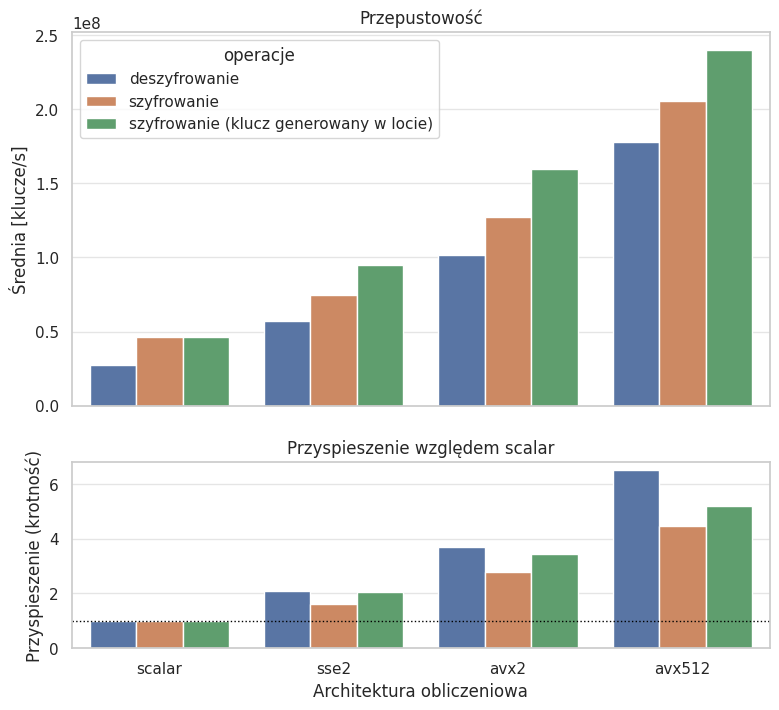

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
sns.barplot(data=engine_backend_function_mean, x='backend', y='mean', hue='function',
            order=backend_order, ax=ax1)
ax1.set_title('Przepustowość')
ax1.set_ylabel('Średnia [klucze/s]')
ax1.set_xlabel('')
handles, labels = ax1.get_legend_handles_labels()
labels = ['deszyfrowanie', 'szyfrowanie', 'szyfrowanie (klucz generowany w locie)']
ax1.legend(handles, labels, title='operacje')


sns.barplot(data=engine_backend_function_mean, x='backend', y='speedup', hue='function',
            order=backend_order, ax=ax2)
ax2.axhline(y=1.0, color='black', linestyle='dotted', linewidth=1)
ax2.set_title('Przyspieszenie względem scalar')
ax2.set_xlabel('Architektura obliczeniowa')
ax2.set_ylabel('Przyspieszenie (krotność)')
ax2.get_legend().remove()

plt.show()

In [14]:
engine_version = mean[(df_stats['benchmark'] == 'engine')].copy()
engine_version.head()

,benchmark,backend,function,version,suffix,mean
0,engine,avx2,decrypt,128_128,1.0,5.113498e+07
1,engine,avx2,decrypt,128_128,2.0,5.120402e+07
2,engine,avx2,decrypt,128_128,3.0,5.118975e+07
3,engine,avx2,decrypt,128_192,1.0,5.049644e+07
4,engine,avx2,decrypt,128_192,2.0,5.077303e+07


In [15]:
engine_version_backend_mean = engine_version.groupby(['backend', 'version'])['mean'].mean().reset_index()
scalar_version_mean = engine_version_backend_mean[engine_version_backend_mean['backend'] == 'scalar'].set_index('version')[
    'mean']
engine_version_backend_mean['speedup'] = engine_version_backend_mean.apply(
    lambda r: r['mean'] / scalar_version_mean[r['version']], axis=1)
engine_version_backend_mean

,backend,version,mean,speedup
0,avx2,128_128,7.065114e+07,1.831980
1,avx2,128_192,6.880923e+07,2.041732
2,avx2,128_256,6.744320e+07,1.785029
3,avx2,32_64,3.242897e+08,4.771266
4,avx2,48_72,1.571684e+08,4.489286
5,avx2,48_96,1.305505e+08,3.791665
6,avx2,64_128,1.653190e+08,2.952998
7,avx2,64_96,1.706608e+08,3.576498
8,avx2,96_144,7.710756e+07,3.205089
9,avx2,96_96,6.274669e+07,2.680582


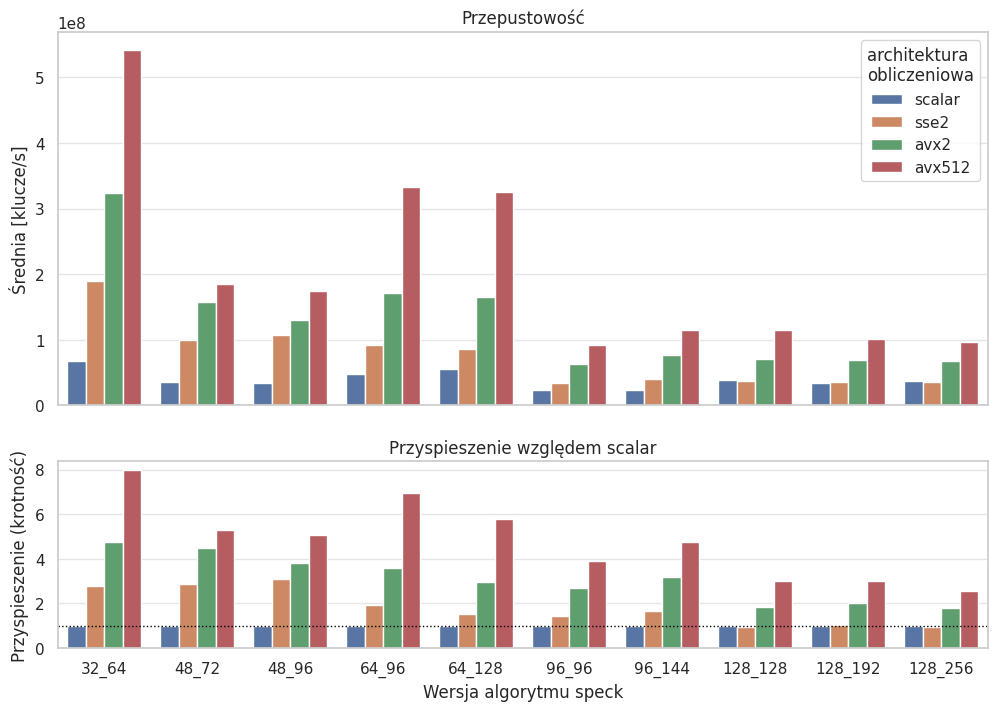

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
sns.barplot(data=engine_version_backend_mean, x='version', y='mean', hue='backend',
            order=version_order, hue_order=backend_order, ax=ax1)
ax1.set_title('Przepustowość')
ax1.set_ylabel('Średnia [klucze/s]')
ax1.set_xlabel('')
ax1.get_legend().set_title('architektura\nobliczeniowa')

sns.barplot(data=engine_version_backend_mean, x='version', y='speedup', hue='backend',
            order=version_order, hue_order=backend_order, ax=ax2)
ax2.axhline(y=1.0, color='black', linestyle='dotted', linewidth=1)
ax2.set_title('Przyspieszenie względem scalar')
ax2.set_xlabel('Wersja algorytmu speck')
ax2.set_ylabel('Przyspieszenie (krotność)')
ax2.get_legend().remove()

plt.show()

In [17]:
engine_speck = mean[(mean['function'] == 'encrypt_inflight')].copy()
engine_speck.head()

,benchmark,backend,function,version,suffix,mean
60,engine,avx2,encrypt_inflight,128_128,1.0,9.367146e+07
61,engine,avx2,encrypt_inflight,128_128,2.0,9.305262e+07
62,engine,avx2,encrypt_inflight,128_128,3.0,9.512205e+07
63,engine,avx2,encrypt_inflight,128_192,1.0,8.937552e+07
64,engine,avx2,encrypt_inflight,128_192,2.0,8.991924e+07


In [18]:
engine_speck = mean[mean['function'] == 'encrypt_inflight'].copy()

engine = (
    engine_speck[engine_speck['benchmark'] == 'engine']
    .assign(suffix=lambda d: d['suffix'].astype('Int64').astype(str))
    .groupby(['backend', 'suffix'], as_index=False)['mean']
    .mean()
)

speck = (
    engine_speck[engine_speck['benchmark'] == 'speck']
    .groupby(['backend'], as_index=False)['mean']
    .mean()
    .rename(columns={'mean': 'speck_mean'})
)

cmp = engine.merge(speck, on='backend', how='left')
cmp['speedup_vs_speck'] = cmp['mean'] / cmp['speck_mean']

throughput_df = pd.concat([
    cmp.assign(series='engine s=' + cmp['suffix'])[['backend', 'mean', 'series']],
    speck.rename(columns={'speck_mean': 'mean'}).assign(series='speck')[['backend', 'mean', 'series']]
], ignore_index=True)

speed_df = pd.concat([
    cmp.assign(series='engine s=' + cmp['suffix'])[['backend', 'speedup_vs_speck', 'series']],
    speck.assign(speedup_vs_speck=1.0, series='speck')[['backend', 'speedup_vs_speck', 'series']]
], ignore_index=True)

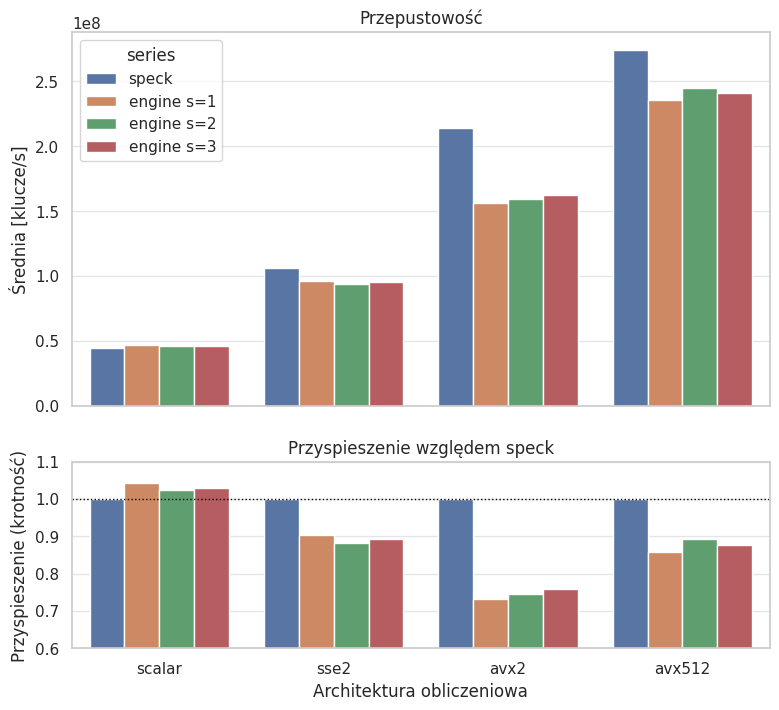

In [19]:
series_order = ['speck', 'engine s=1', 'engine s=2', 'engine s=3']
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

sns.barplot(data=throughput_df, x='backend', y='mean', hue='series',
            order=backend_order, hue_order=series_order, ax=ax1)
ax1.set_title('Przepustowość')
ax1.set_ylabel('Średnia [klucze/s]')
ax1.set_xlabel('')

sns.barplot(data=speed_df, x='backend', y='speedup_vs_speck', hue='series',
            order=backend_order, hue_order=series_order, ax=ax2)
ax2.axhline(1.0, color='black', linestyle='dotted', linewidth=1)
ax2.set_title('Przyspieszenie względem speck')
ax2.set_xlabel('Architektura obliczeniowa')
ax2.set_ylabel('Przyspieszenie (krotność)')
ax2.set_ylim(0.6, 1.1)
ax2.get_legend().remove()

plt.show()